# 04c — Statistical Comparison (Weekly Version)
## Prophet vs SARIMA at Weekly Granularity — Pick the Winner

**Decision criteria (pre-registered, same as daily version):**
1. **Primary:** WAPE on validation
2. **Tiebreaker 1:** R² on validation
3. **Tiebreaker 2:** |Bias| on validation
4. **Sanity check:** both must beat seasonal naive

The winner advances to notebook 07 as the statistical baseline. ML and DL
models from later notebooks must beat it to be deployment-recommended.

---

## 1. Setup and load both models' outputs

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATASETS_DIR = '../../datasets'
SARIMA_DIR = '../Sarima'
PROPHET_DIR ='../Prophet'
df = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Load predictions
prophet_pred = pd.read_csv(os.path.join(PROPHET_DIR, 'prophet_predictions_weekly.csv'),
                            parse_dates=['ds'])
sarima_pred = pd.read_csv(os.path.join(SARIMA_DIR, 'sarima_predictions_weekly.csv'),
                           parse_dates=['ds'])

# Load metrics
prophet_metrics = pd.read_csv(os.path.join(PROPHET_DIR, 'prophet_metrics_weekly.csv'))
sarima_metrics = pd.read_csv(os.path.join(SARIMA_DIR, 'sarima_metrics_weekly.csv'))

# Load summaries
with open(os.path.join(PROPHET_DIR, 'prophet_summary_weekly.json')) as f:
    prophet_summary = json.load(f)
with open(os.path.join(SARIMA_DIR, 'sarima_summary_weekly.json')) as f:
    sarima_summary = json.load(f)

print(f"Prophet: {len(prophet_pred):,} predictions, {prophet_metrics['item_name'].nunique()} items")
print(f"SARIMA:  {len(sarima_pred):,} predictions, {sarima_metrics['item_name'].nunique()} items")

Prophet: 6,344 predictions, 122 items
SARIMA:  6,344 predictions, 122 items


## 2. Side-by-side overall metrics

OVERALL METRICS — Prophet vs SARIMA (weekly)
  Model Split    MAE   RMSE   MAPE  SMAPE   WAPE  MASE     R2    BIAS
Prophet   val 2.8865 3.7282 0.6367 0.4287 0.3734   NaN 0.4937 -0.7891
 SARIMA   val 3.1068 3.9865 0.7158 0.4460 0.4019   NaN 0.4211 -1.3036
Prophet  test 2.9010 3.7452 0.4153 0.3322 0.2837   NaN 0.6196 -0.0743
 SARIMA  test 2.9314 3.9256 0.3739 0.3286 0.2867   NaN 0.5821  1.0429


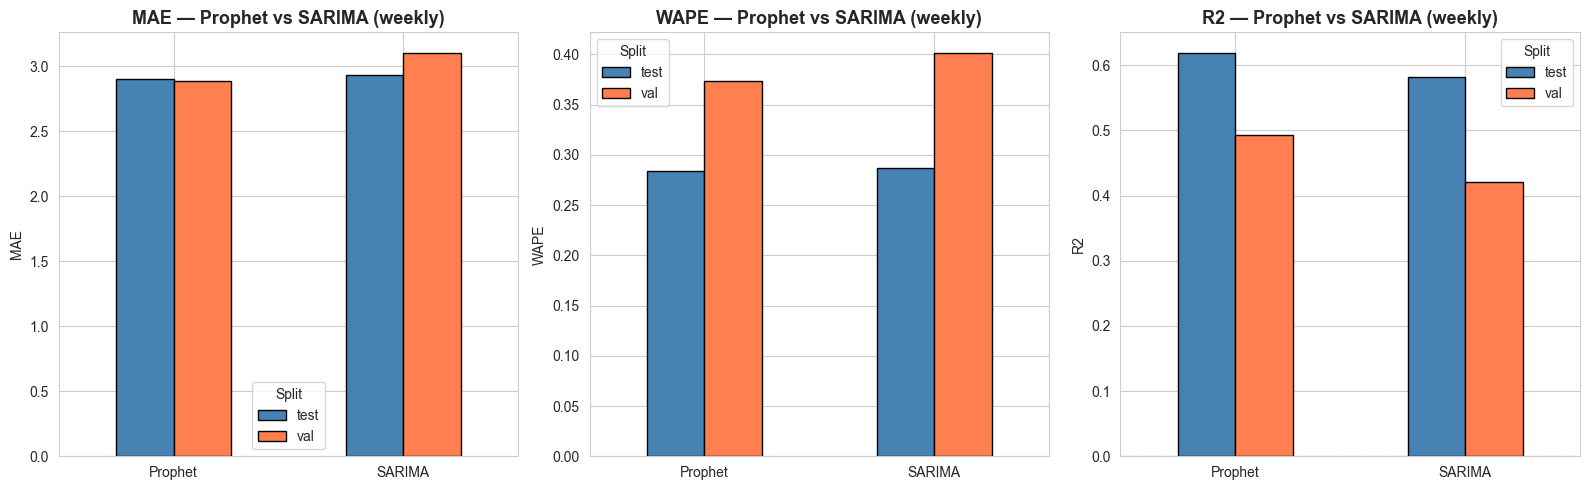

In [2]:
rows = []
for split in ['val', 'test']:
    rows.append({
        'Model': 'Prophet', 'Split': split,
        **{k.upper(): v for k, v in prophet_summary['overall_metrics'][split].items()}
    })
    rows.append({
        'Model': 'SARIMA', 'Split': split,
        **{k.upper(): v for k, v in sarima_summary['overall_metrics'][split].items()}
    })

overall_df = pd.DataFrame(rows)
print("=" * 90)
print("OVERALL METRICS — Prophet vs SARIMA (weekly)")
print("=" * 90)
print(overall_df.to_string(index=False, float_format='%.4f'))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['MAE', 'WAPE', 'R2']):
    pivot = overall_df.pivot(index='Model', columns='Split', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric} — Prophet vs SARIMA (weekly)')
    ax.set_ylabel(metric); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Split')
    if metric == 'R2':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('weekly_overall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-item head-to-head: how often does each model win?

HEAD-TO-HEAD WIN COUNTS (per item, weekly)

— VAL (122 items) —
  WAPE : Prophet 69/122 (56.6%)  |  SARIMA 53/122 (43.4%)
  MAE  : Prophet 69/122 (56.6%)  |  SARIMA 53/122 (43.4%)
  R2   : Prophet 72/122 (59.0%)  |  SARIMA 50/122 (41.0%)

— TEST (122 items) —
  WAPE : Prophet 49/122 (40.2%)  |  SARIMA 73/122 (59.8%)
  MAE  : Prophet 49/122 (40.2%)  |  SARIMA 73/122 (59.8%)
  R2   : Prophet 60/122 (49.2%)  |  SARIMA 62/122 (50.8%)



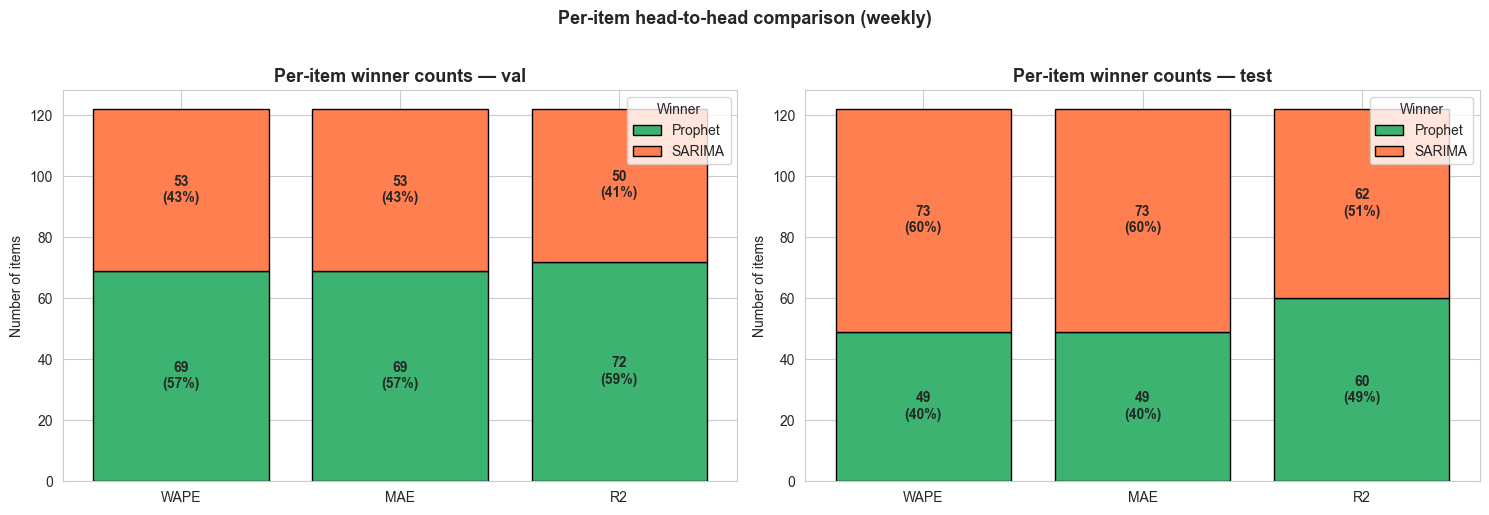

In [3]:
head_to_head = []
for split in ['val', 'test']:
    p = prophet_metrics[prophet_metrics['split'] == split].set_index('item_name')
    s = sarima_metrics[sarima_metrics['split'] == split].set_index('item_name')
    common = p.index.intersection(s.index)

    for metric_name in ['wape', 'mae', 'r2']:
        if metric_name == 'r2':
            prophet_wins = (p.loc[common, metric_name] > s.loc[common, metric_name]).sum()
        else:
            prophet_wins = (p.loc[common, metric_name] < s.loc[common, metric_name]).sum()
        sarima_wins = len(common) - prophet_wins
        head_to_head.append({
            'Split': split, 'Metric': metric_name.upper(),
            'Prophet_wins': prophet_wins, 'SARIMA_wins': sarima_wins,
            'Total': len(common),
        })

h2h_df = pd.DataFrame(head_to_head)

print("=" * 70)
print("HEAD-TO-HEAD WIN COUNTS (per item, weekly)")
print("=" * 70)
print()
for split in ['val', 'test']:
    print(f"— {split.upper()} ({h2h_df[h2h_df['Split']==split]['Total'].iloc[0]} items) —")
    for _, row in h2h_df[h2h_df['Split']==split].iterrows():
        prophet_pct = row['Prophet_wins'] / row['Total'] * 100
        sarima_pct = row['SARIMA_wins'] / row['Total'] * 100
        print(f"  {row['Metric']:<5s}: Prophet {row['Prophet_wins']}/{row['Total']} ({prophet_pct:.1f}%)  |  SARIMA {row['SARIMA_wins']}/{row['Total']} ({sarima_pct:.1f}%)")
    print()

# Stacked bar visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, split in zip(axes, ['val', 'test']):
    sub = h2h_df[h2h_df['Split'] == split]
    metrics_list = sub['Metric'].values
    prophet_w = sub['Prophet_wins'].values
    sarima_w = sub['SARIMA_wins'].values

    x = np.arange(len(metrics_list))
    ax.bar(x, prophet_w, label='Prophet', color='mediumseagreen', edgecolor='black')
    ax.bar(x, sarima_w, bottom=prophet_w, label='SARIMA', color='coral', edgecolor='black')

    for i, (p, s) in enumerate(zip(prophet_w, sarima_w)):
        total = p + s
        ax.text(i, p/2, f'{p}\n({p/total*100:.0f}%)', ha='center', va='center', fontsize=10, fontweight='bold')
        ax.text(i, p + s/2, f'{s}\n({s/total*100:.0f}%)', ha='center', va='center', fontsize=10, fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels(metrics_list)
    ax.set_ylabel('Number of items')
    ax.set_title(f'Per-item winner counts — {split}')
    ax.legend(title='Winner')

plt.suptitle('Per-item head-to-head comparison (weekly)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('weekly_head_to_head.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-section comparison

PER-SECTION WAPE COMPARISON (lower = better, weekly)
      section split  n_items  wape_prophet  wape_sarima  wape_diff better_model
     American  test       21        0.2914       0.2776     0.0138       SARIMA
         Cafe  test       17        0.2539       0.2819    -0.0281      Prophet
Healthy_Vegan  test       12        0.3745       0.3455     0.0289       SARIMA
      Italian  test       22        0.3113       0.3151    -0.0038      Prophet
     Japanese  test       16        0.3390       0.3317     0.0073       SARIMA
      Mexican  test       19        0.3334       0.3066     0.0268       SARIMA
   Steakhouse  test       15        0.3620       0.3512     0.0107       SARIMA
     American   val       21        0.3988       0.3920     0.0068       SARIMA
         Cafe   val       17        0.3842       0.4605    -0.0763      Prophet
Healthy_Vegan   val       12        0.4867       0.5587    -0.0720      Prophet
      Italian   val       22        0.4363       0.4924    -0.0562 

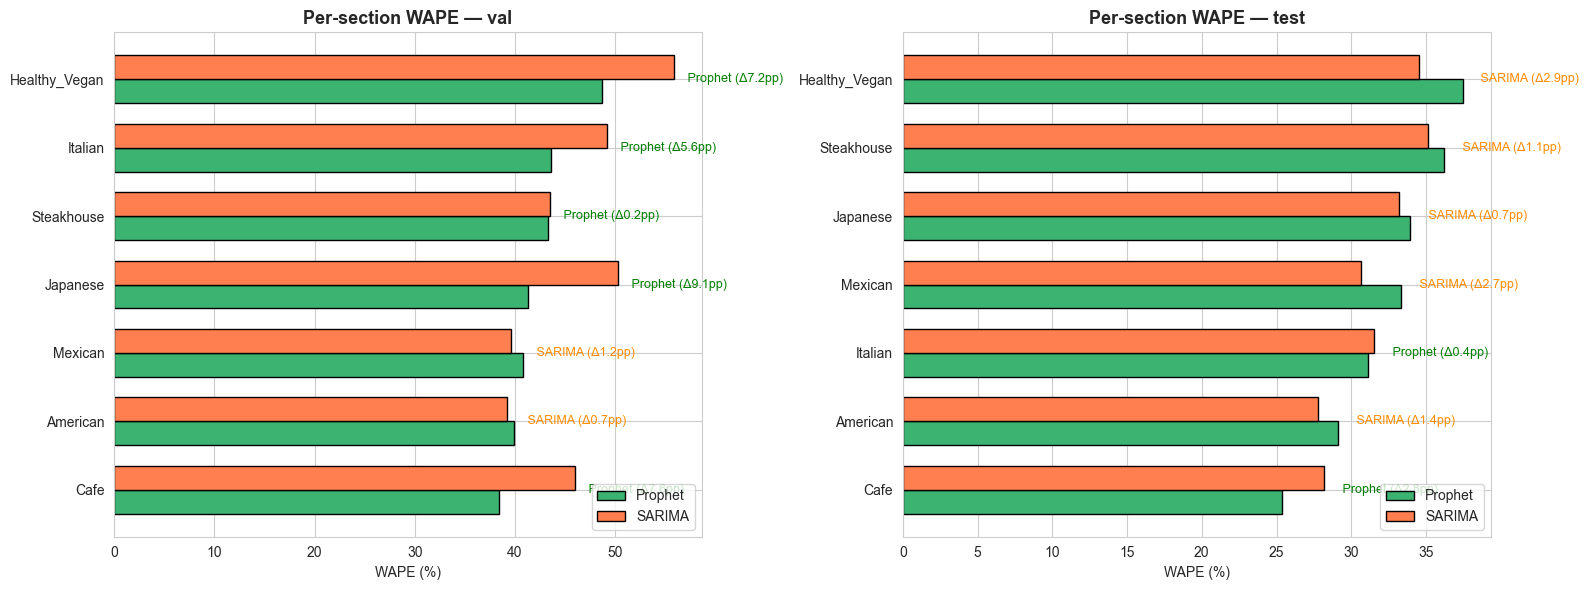

In [4]:
section_compare = []
for split in ['val', 'test']:
    p_sec = prophet_summary['per_section_metrics'][split]
    s_sec = sarima_summary['per_section_metrics'][split]
    sections = sorted(set(p_sec.keys()) & set(s_sec.keys()))

    for sec in sections:
            # Clean way to count items using the main df
            n_items = df[df['section'] == sec]['item_name'].nunique()
            
            section_compare.append({
                'section': sec, 'split': split,
                'n_items': n_items,
                'wape_prophet': p_sec[sec]['wape'],
                'wape_sarima': s_sec[sec]['wape'],
                'wape_diff': p_sec[sec]['wape'] - s_sec[sec]['wape'],
                'better_model': 'Prophet' if p_sec[sec]['wape'] < s_sec[sec]['wape'] else 'SARIMA',
            })

sec_df = pd.DataFrame(section_compare).sort_values(['split', 'section'])
print("=" * 90)
print("PER-SECTION WAPE COMPARISON (lower = better, weekly)")
print("=" * 90)
print(sec_df.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, split in zip(axes, ['val', 'test']):
    sub = sec_df[sec_df['split']==split].sort_values('wape_prophet')
    x = np.arange(len(sub))
    width = 0.35
    ax.barh(x - width/2, sub['wape_prophet']*100, width, label='Prophet', color='mediumseagreen', edgecolor='black')
    ax.barh(x + width/2, sub['wape_sarima']*100, width, label='SARIMA', color='coral', edgecolor='black')

    for i, (p, s, better) in enumerate(zip(sub['wape_prophet']*100, sub['wape_sarima']*100, sub['better_model'])):
        diff = abs(p - s)
        color = 'green' if better == 'Prophet' else 'darkorange'
        x_pos = max(p, s) + 1
        ax.text(x_pos, i, f' {better} (Δ{diff:.1f}pp)', va='center', fontsize=9, color=color)

    ax.set_yticks(x); ax.set_yticklabels(sub['section'])
    ax.set_xlabel('WAPE (%)'); ax.set_title(f'Per-section WAPE — {split}')
    ax.legend()

plt.tight_layout()
plt.savefig('weekly_per_section_compare.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-volume-tier comparison

PER-VOLUME-TIER COMPARISON (weekly)
     volume_tier split  wape_prophet  wape_sarima  r2_prophet  r2_sarima
Medium (7-35/wk)   val        0.3771       0.4289     -0.3890    -0.7683
     Low (<7/wk)   val        0.4900       0.5021     -0.3395    -0.3393
Medium (7-35/wk)  test        0.2740       0.2809     -0.1618    -0.2430
     Low (<7/wk)  test        0.3945       0.3642     -0.2295    -0.0851


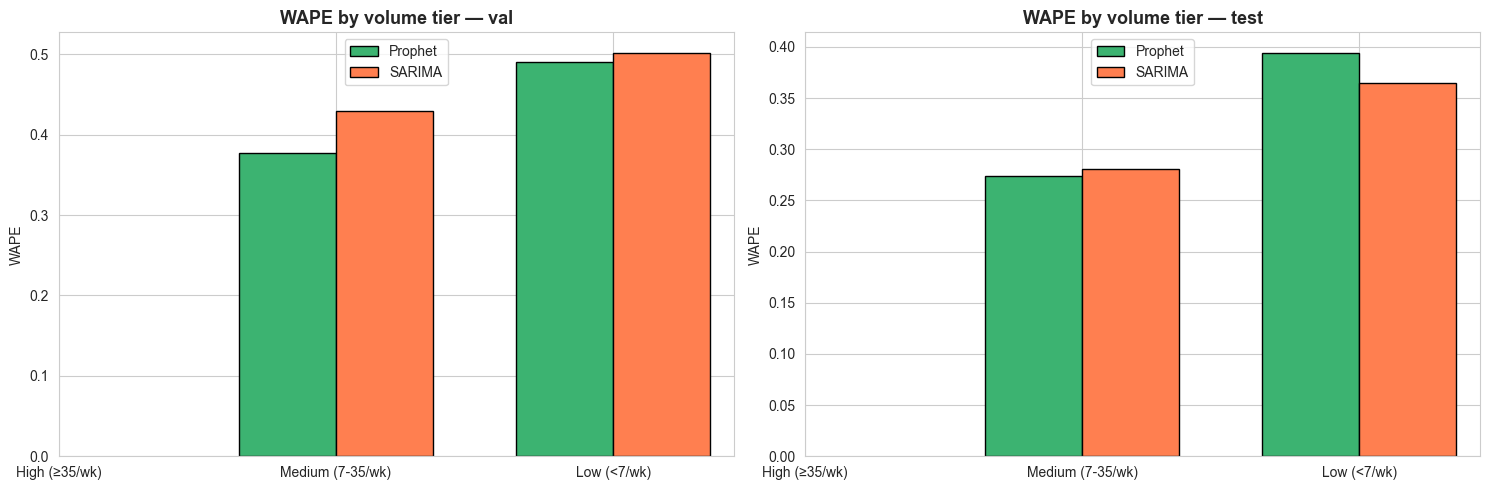

In [5]:
tier_compare = []
for split in ['val', 'test']:
    p_tier = prophet_summary['per_volume_tier_metrics'][split]
    s_tier = sarima_summary['per_volume_tier_metrics'][split]

    for tier in p_tier.keys():
        if tier in s_tier:
            tier_compare.append({
                'volume_tier': tier, 'split': split,
                'wape_prophet': p_tier[tier]['wape'],
                'wape_sarima': s_tier[tier]['wape'],
                'r2_prophet': p_tier[tier]['r2'],
                'r2_sarima': s_tier[tier]['r2'],
            })

tier_df = pd.DataFrame(tier_compare)
print("=" * 80)
print("PER-VOLUME-TIER COMPARISON (weekly)")
print("=" * 80)
print(tier_df.to_string(index=False, float_format='%.4f'))

tier_order = ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, split in zip(axes, ['val', 'test']):
    sub = tier_df[tier_df['split']==split].set_index('volume_tier').reindex(tier_order)
    x = np.arange(len(sub))
    width = 0.35
    ax.bar(x - width/2, sub['wape_prophet'], width, label='Prophet', color='mediumseagreen', edgecolor='black')
    ax.bar(x + width/2, sub['wape_sarima'], width, label='SARIMA', color='coral', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(sub.index)
    ax.set_ylabel('WAPE'); ax.set_title(f'WAPE by volume tier — {split}')
    ax.legend()

plt.tight_layout()
plt.savefig('weekly_per_tier_compare.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Per-item WAPE scatter

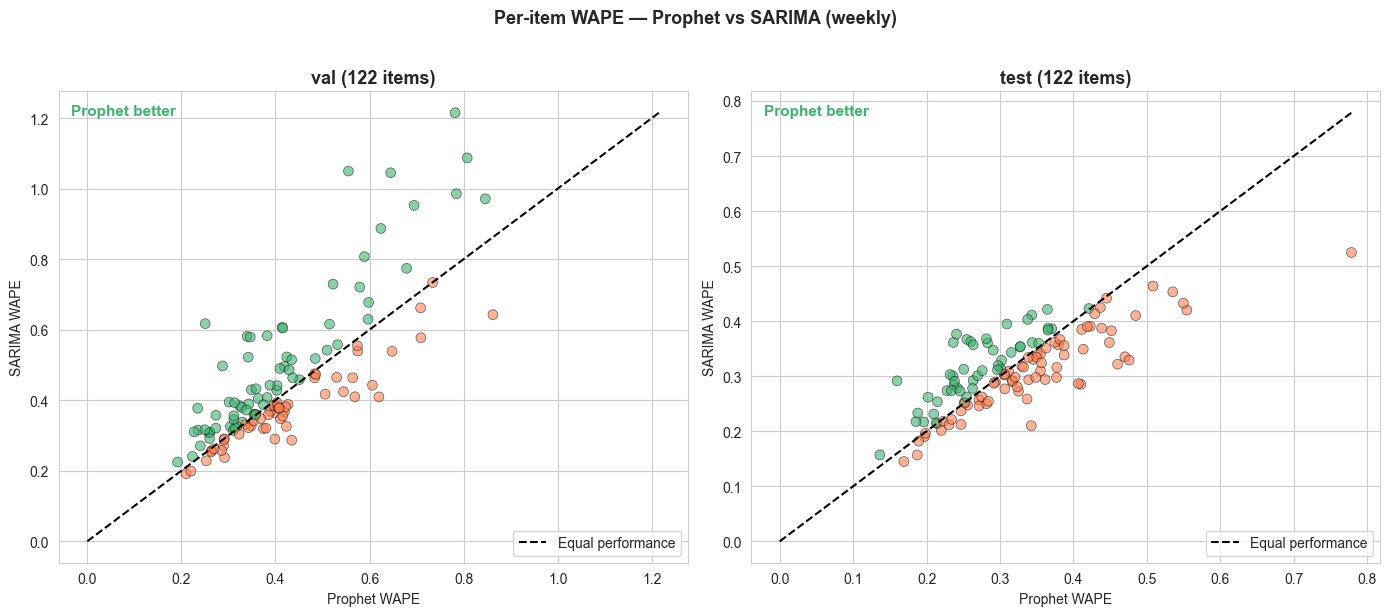

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, split in zip(axes, ['val', 'test']):
    p = prophet_metrics[prophet_metrics['split']==split].set_index('item_name')['wape']
    s = sarima_metrics[sarima_metrics['split']==split].set_index('item_name')['wape']
    common = p.index.intersection(s.index)

    p_vals = p.loc[common].clip(upper=2)
    s_vals = s.loc[common].clip(upper=2)

    colors = ['mediumseagreen' if pv < sv else 'coral' for pv, sv in zip(p_vals, s_vals)]
    ax.scatter(p_vals, s_vals, c=colors, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)

    max_val = max(p_vals.max(), s_vals.max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, label='Equal performance')
    ax.set_xlabel('Prophet WAPE'); ax.set_ylabel('SARIMA WAPE')
    ax.set_title(f'{split} ({len(common)} items)')
    ax.legend(loc='lower right')
    ax.text(0.02, 0.95, 'Prophet better', transform=ax.transAxes,
            fontsize=11, color='mediumseagreen', fontweight='bold')

plt.suptitle('Per-item WAPE — Prophet vs SARIMA (weekly)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('weekly_per_item_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Wilcoxon signed-rank test

Non-parametric paired test for whether Prophet's WAPE is significantly different
from SARIMA's WAPE across items. Same test as the daily comparison.

In [7]:
wilcoxon_results = []

for split in ['val', 'test']:
    p = prophet_metrics[prophet_metrics['split']==split].set_index('item_name')['wape']
    s = sarima_metrics[sarima_metrics['split']==split].set_index('item_name')['wape']
    common = p.index.intersection(s.index)

    diffs = p.loc[common].values - s.loc[common].values

    if (diffs == 0).all():
        result = {'Split': split, 'N': len(common), 'Median_diff': 0, 'P_value': 1.0,
                  'Significant': False, 'Direction': 'tied'}
    else:
        stat, pval = stats.wilcoxon(diffs)
        median_diff = np.median(diffs)
        mean_diff = np.mean(diffs)
        # effect size (Wilcoxon r = Z / sqrt(N))
        z = stats.norm.ppf(1 - pval/2) * np.sign(median_diff)
        effect_size = abs(z) / np.sqrt(len(common))

        result = {
            'Split': split,
            'N': len(common),
            'Median_diff': median_diff,
            'Mean_diff': mean_diff,
            'Statistic': stat,
            'P_value': pval,
            'Effect_size': effect_size,
            'Significant': pval < 0.05,
            'Direction': 'Prophet better' if median_diff < 0 else 'SARIMA better' if median_diff > 0 else 'tied',
        }

    wilcoxon_results.append(result)

wil_df = pd.DataFrame(wilcoxon_results)
print("=" * 80)
print("WILCOXON SIGNED-RANK TEST (paired, non-parametric)")
print("H0: Prophet and SARIMA WAPEs come from the same distribution")
print("=" * 80)
print()
for _, r in wil_df.iterrows():
    print(f"— {r['Split'].upper()} —")
    print(f"  N items:           {r['N']}")
    print(f"  Median WAPE diff:  {r['Median_diff']:+.4f}  (Prophet − SARIMA)")
    if 'Mean_diff' in r:
        print(f"  Mean WAPE diff:    {r['Mean_diff']:+.4f}")
        print(f"  Test statistic:    {r['Statistic']:.1f}")
        print(f"  p-value:           {r['P_value']:.6f}")
        print(f"  Effect size:       {r['Effect_size']:+.3f}")
    sig = "✓ Significant" if r['Significant'] else "✗ Not significant"
    print(f"  Result:            {sig} (α=0.05)")
    print()

WILCOXON SIGNED-RANK TEST (paired, non-parametric)
H0: Prophet and SARIMA WAPEs come from the same distribution

— VAL —
  N items:           122
  Median WAPE diff:  -0.0106  (Prophet − SARIMA)
  Mean WAPE diff:    -0.0368
  Test statistic:    2646.0
  p-value:           0.004735
  Effect size:       +0.256
  Result:            ✓ Significant (α=0.05)

— TEST —
  N items:           122
  Median WAPE diff:  +0.0072  (Prophet − SARIMA)
  Mean WAPE diff:    +0.0071
  Test statistic:    3301.0
  p-value:           0.249722
  Effect size:       +0.104
  Result:            ✗ Not significant (α=0.05)



## 8. Strategic trade-offs table

In [8]:
tradeoffs = pd.DataFrame([
    {'Dimension': 'Training time (122 items)',
     'Prophet': f"~{prophet_summary['training_time_seconds']:.0f}s",
     'SARIMA': f"~{sarima_summary['training_time_seconds']:.0f}s"},
    {'Dimension': 'Calendar awareness',
     'Prophet': 'Explicit (Ramadan, Eid, NYE, national)',
     'SARIMA': 'None — pure autocorrelation'},
    {'Dimension': 'Interpretability',
     'Prophet': 'Native component decomposition (XAI-ready)',
     'SARIMA': 'Statistical only (AR/MA coefficients)'},
    {'Dimension': 'Confidence intervals',
     'Prophet': 'Bayesian posterior',
     'SARIMA': 'Frequentist (from fitted model)'},
    {'Dimension': 'Persistence format',
     'Prophet': 'Native JSON',
     'SARIMA': 'Pickle'},
    {'Dimension': 'Per-item prediction quality',
     'Prophet': 'Captures monthly + yearly seasonality visibly',
     'SARIMA': 'Often collapses to flat near-mean predictions'},
    {'Dimension': 'Regime change handling',
     'Prophet': 'Anticipates Ramadan via holidays feature',
     'SARIMA': 'Lags regime changes, persistent bias errors'},
])
print("=" * 100)
print("STRATEGIC TRADE-OFFS")
print("=" * 100)
print(tradeoffs.to_string(index=False))

STRATEGIC TRADE-OFFS
                  Dimension                                       Prophet                                        SARIMA
  Training time (122 items)                                          ~27s                                        ~1029s
         Calendar awareness        Explicit (Ramadan, Eid, NYE, national)                   None — pure autocorrelation
           Interpretability    Native component decomposition (XAI-ready)         Statistical only (AR/MA coefficients)
       Confidence intervals                            Bayesian posterior               Frequentist (from fitted model)
         Persistence format                                   Native JSON                                        Pickle
Per-item prediction quality Captures monthly + yearly seasonality visibly Often collapses to flat near-mean predictions
     Regime change handling      Anticipates Ramadan via holidays feature   Lags regime changes, persistent bias errors


## 9. Decision report

Apply the pre-registered decision criteria in order.

In [9]:
prophet_val_wape = prophet_summary['overall_metrics']['val']['wape']
sarima_val_wape = sarima_summary['overall_metrics']['val']['wape']
prophet_val_r2 = prophet_summary['overall_metrics']['val']['r2']
sarima_val_r2 = sarima_summary['overall_metrics']['val']['r2']
prophet_val_bias = abs(prophet_summary['overall_metrics']['val']['bias'])
sarima_val_bias = abs(sarima_summary['overall_metrics']['val']['bias'])

# Seasonal naive baseline
seasonal_naive_val_wape = prophet_summary['baseline_comparison'].get('seasonal_naive_val', {}).get('wape', None)

print("=" * 70)
print("DECISION REPORT")
print("=" * 70)
print()

print("[1] PRIMARY CRITERION — WAPE on validation")
print(f"    Prophet:  {prophet_val_wape:.4f}")
print(f"    SARIMA:   {sarima_val_wape:.4f}")
diff_pct = (sarima_val_wape - prophet_val_wape) / sarima_val_wape * 100
print(f"    Diff:     {diff_pct:+.1f}%")
primary_winner = 'Prophet' if prophet_val_wape < sarima_val_wape else 'SARIMA'
print(f"    Winner:   {primary_winner}")

print()
print("[2] TIEBREAKER 1 — R² on validation")
print(f"    Prophet:  {prophet_val_r2:+.4f}")
print(f"    SARIMA:   {sarima_val_r2:+.4f}")
r2_winner = 'Prophet' if prophet_val_r2 > sarima_val_r2 else 'SARIMA'
print(f"    Winner:   {r2_winner}")

print()
print("[3] TIEBREAKER 2 — |Bias| on validation")
print(f"    Prophet:  {prophet_val_bias:.4f}")
print(f"    SARIMA:   {sarima_val_bias:.4f}")
bias_winner = 'Prophet' if prophet_val_bias < sarima_val_bias else 'SARIMA'
print(f"    Winner:   {bias_winner}")

print()
if seasonal_naive_val_wape:
    print(f"[4] SANITY CHECK — Both must beat seasonal naive (WAPE {seasonal_naive_val_wape:.4f})")
    print(f"    Prophet beats naive: {'✓' if prophet_val_wape < seasonal_naive_val_wape else '✗'}")
    print(f"    SARIMA beats naive:  {'✓' if sarima_val_wape < seasonal_naive_val_wape else '✗'}")

print()
print("=" * 70)
votes = [primary_winner, r2_winner, bias_winner]
prophet_votes = votes.count('Prophet')
sarima_votes = votes.count('SARIMA')
overall = 'Prophet' if prophet_votes > sarima_votes else 'SARIMA'
print(f"FINAL DECISION: {overall} advances to notebook 07")
print(f"Vote: Prophet {prophet_votes} – SARIMA {sarima_votes}")
print("=" * 70)

DECISION REPORT

[1] PRIMARY CRITERION — WAPE on validation
    Prophet:  0.3734
    SARIMA:   0.4019
    Diff:     +7.1%
    Winner:   Prophet

[2] TIEBREAKER 1 — R² on validation
    Prophet:  +0.4937
    SARIMA:   +0.4211
    Winner:   Prophet

[3] TIEBREAKER 2 — |Bias| on validation
    Prophet:  0.7891
    SARIMA:   1.3036
    Winner:   Prophet

[4] SANITY CHECK — Both must beat seasonal naive (WAPE 0.5961)
    Prophet beats naive: ✓
    SARIMA beats naive:  ✓

FINAL DECISION: Prophet advances to notebook 07
Vote: Prophet 3 – SARIMA 0


## 10. Save comparison summary

In [10]:
comparison_summary = {
    'comparison': 'prophet_vs_sarima_weekly',
    'granularity': 'weekly',
    'overall_metrics': {
        'prophet': prophet_summary['overall_metrics'],
        'sarima': sarima_summary['overall_metrics'],
    },
    'head_to_head': h2h_df.to_dict('records'),
    'wilcoxon_results': wil_df.to_dict('records'),
    'decision': {
        'primary_winner': primary_winner,
        'r2_winner': r2_winner,
        'bias_winner': bias_winner,
        'overall_winner': overall,
        'votes': {'Prophet': prophet_votes, 'SARIMA': sarima_votes},
    },
}

with open(os.path.join(DATASETS_DIR, 'statistical_comparison_weekly.json'), 'w') as f:
    json.dump(comparison_summary, f, indent=2, default=str)

print(f"✓ Saved: {DATASETS_DIR}/statistical_comparison_weekly.json")
print(f"\nThe winning statistical model is: {overall}")
print(f"\nNext: 05a_xgboost_global_weekly.ipynb + 05b_lightgbm_global_weekly.ipynb")

✓ Saved: ../../datasets/statistical_comparison_weekly.json

The winning statistical model is: Prophet

Next: 05a_xgboost_global_weekly.ipynb + 05b_lightgbm_global_weekly.ipynb
